In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import *
from src.environment import HotelPricingEnv
from src.dqn_agent import DQNAgent

In [2]:
env = HotelPricingEnv()

agent = DQNAgent(state_size=2,action_size=len(PRICE_LEVELS),learning_rate=0.001,gamma=0.99,
                 epsilon=0,epsilon_min=0.05,epsilon_decay=0.998,memory_size=20000,batch_size=128)

agent.model.load_state_dict(torch.load("../models/dqn_model.pth"))

agent.model.eval()

print("DQN model loaded successfully.")

DQN model loaded successfully.


In [3]:
episodes = 100
results = []

for episode in range(episodes):
    state,info = env.reset()
    done = False

    revenue = 0
    rooms = 0
    total_price = 0
    total_days = 0

    while not done:
        action = agent.select_action(state)
        price = PRICE_LEVELS[action]

        next_state,reward,done,_,info = env.step(action)

        revenue += reward
        rooms += info["rooms_sold"]
        total_price += price
        total_days += 1

        state =next_state

    occupancy = (rooms / TOTAL_ROOMS) * 100

    results.append({
        "Revenue": revenue,
        "Rooms Sold": rooms,
        "Occupancy (%)": occupancy,
        "Average Price": total_price / total_days
    })

results = pd.DataFrame(results)
results.head()


,Revenue,Rooms Sold,Occupancy (%),Average Price
0,3095,37,74.0,118.666667
1,3365,39,78.0,117.333333
2,3475,41,82.0,118.666667
3,2915,33,66.0,117.333333
4,4085,47,94.0,122.000000


In [4]:
summary = pd.DataFrame({
    "Metric":["Average Revenue",
              "Average Rooms Sold",
              "Average Occupancy (%)",
              "Average Price"],
    "Value":[results["Revenue"].mean(),
             results["Rooms Sold"].mean(),
             results["Occupancy (%)"].mean(),
             results["Average Price"].mean()]
})
summary

,Metric,Value
0,Average Revenue,3391.300000
1,Average Rooms Sold,40.020000
2,Average Occupancy (%),80.040000
3,Average Price,118.060985


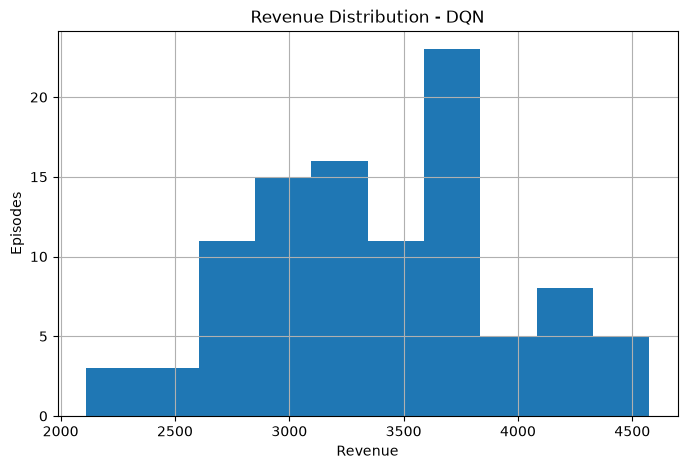

In [5]:
plt.figure(figsize=(8,5))

plt.hist(results["Revenue"], bins=10)

plt.title("Revenue Distribution - DQN")

plt.xlabel("Revenue")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

In [6]:
week2 = pd.read_csv(r"E:\AARAV\Infotact-DS-ML\Project-2-Dynamic-Pricing\data\processed\week2_final_comparison.csv")

week2

,Strategy,Average Revenue,Average Rooms Sold,Average Occupancy (%),Average Price,Episodes
0,Fixed,3638.50,38.30,76.60,120.000000,50
1,Random,3202.10,37.74,75.48,119.493333,50
2,Discount,3051.50,36.58,73.16,126.666667,50
3,Q-Learning,2908.25,46.63,93.26,92.413690,100


In [7]:
dqn_row = pd.DataFrame({
    "Strategy": ["Deep Q-Network"],
    "Average Revenue": [results["Revenue"].mean()],
    "Average Rooms Sold": [results["Rooms Sold"].mean()],
    "Average Occupancy (%)": [results["Occupancy (%)"].mean()],
    "Average Price": [results["Average Price"].mean()],
    "Episodes": [episodes]
})

comparison = pd.concat([week2, dqn_row],ignore_index=True)

comparison

,Strategy,Average Revenue,Average Rooms Sold,Average Occupancy (%),Average Price,Episodes
0,Fixed,3638.50,38.30,76.60,120.000000,50
1,Random,3202.10,37.74,75.48,119.493333,50
2,Discount,3051.50,36.58,73.16,126.666667,50
3,Q-Learning,2908.25,46.63,93.26,92.413690,100
4,Deep Q-Network,3391.30,40.02,80.04,118.060985,100


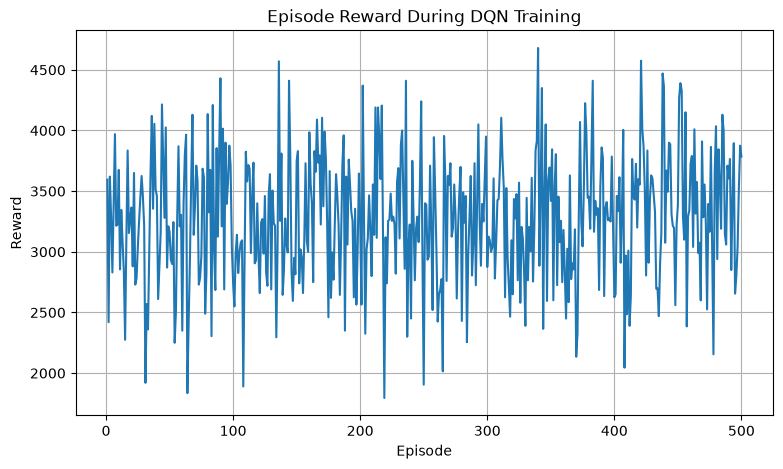

In [8]:
history = pd.read_csv(r"E:\AARAV\Infotact-DS-ML\Project-2-Dynamic-Pricing\data\processed\dqn_training_history.csv")

plt.figure(figsize=(9,5))

plt.plot(history["Episode"],history["Reward"])

plt.title("Episode Reward During DQN Training")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

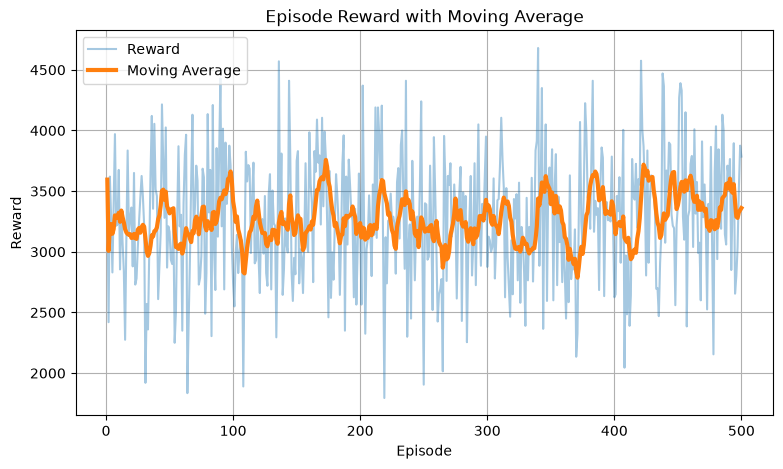

In [10]:
history["Moving Average Reward"] = (history["Reward"].rolling(window=10,min_periods=1).mean())

plt.figure(figsize=(9,5))

plt.plot(history["Episode"],history["Reward"],alpha=0.4,label="Reward")

plt.plot(history["Episode"],history["Moving Average Reward"],linewidth=3,label="Moving Average")

plt.title("Episode Reward with Moving Average")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.legend()

plt.grid(True)

plt.show()

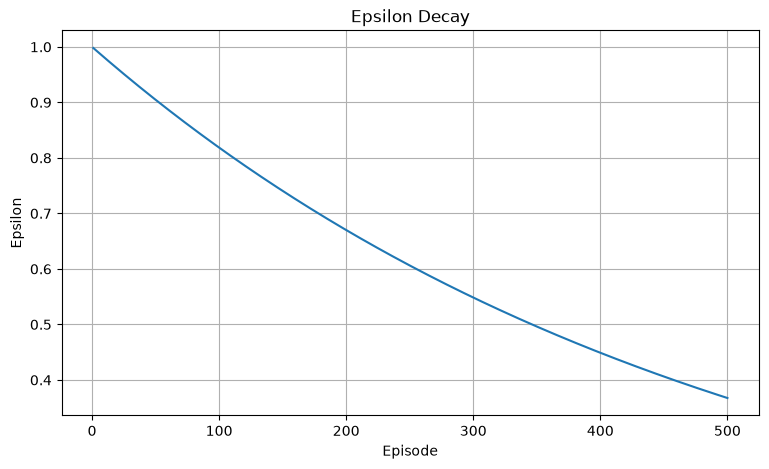

In [11]:
plt.figure(figsize=(9,5))

plt.plot(history["Episode"],history["Epsilon"])

plt.title("Epsilon Decay")

plt.xlabel("Episode")

plt.ylabel("Epsilon")

plt.grid(True)

plt.show()

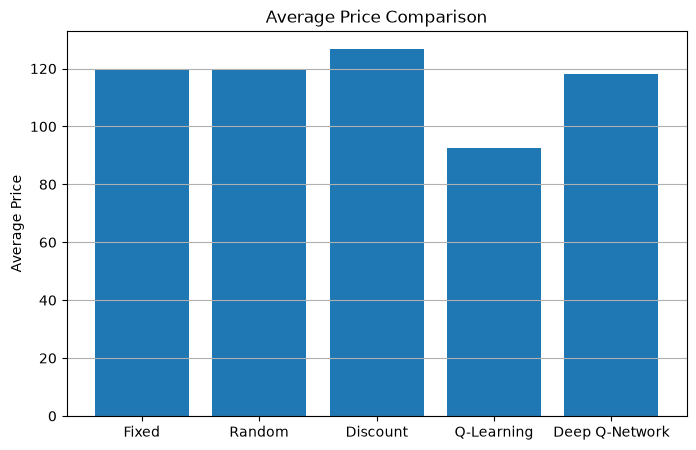

In [12]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Strategy"],comparison["Average Price"])

plt.title("Average Price Comparison")

plt.ylabel("Average Price")

plt.grid(axis="y")

plt.show()

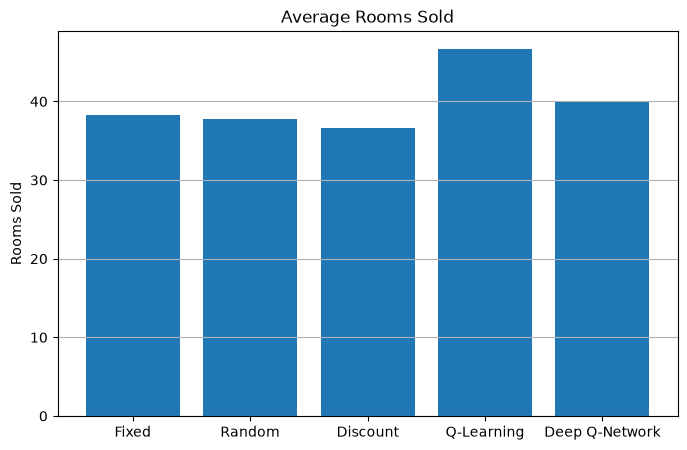

In [13]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Strategy"],comparison["Average Rooms Sold"])

plt.title("Average Rooms Sold")

plt.ylabel("Rooms Sold")

plt.grid(axis="y")

plt.show()